# Matplotlib - Data Visualisation in Python

Matplotlib is the standard library for creating plots in Python.

You use it when you want to:
- visualise numerical data (time series, distributions, comparisons)
- explore a dataset before analysing it
- produce figures for reports or presentations

There is also **Seaborn**, a library built on top of Matplotlib with a higher-level interface and more sophisticated charts - it is not covered by this course. 

---

## How to use this notebook

- Run each cell with `Shift + Enter`.
- After running a cell, change some values and run it again: that is the fastest way to understand what each parameter does.
- Read the inline comments in the code — they explain the key choices.

---

## 0. Install and import

If you are running this locally and matplotlib is missing, install it with:

```bash
conda install matplotlib
```

Now import it:

## 0. Imports

The standard convention is to import the `pyplot` module with the alias `plt`.
NumPy is almost always needed alongside Matplotlib to generate the data to plot.

In [5]:
import matplotlib.pyplot as plt
import numpy as np

---

# 1. Two interfaces: stateful vs object-oriented

Matplotlib offers two ways of working:

1. **Stateful (MATLAB style)** — functions are called via `plt.` and always act on the "current" figure and axes. Convenient for quick scripts, but hard to manage when you have multiple plots.

2. **Object-oriented (recommended)** — you explicitly create a `Figure` and one or more `Axes` objects, then call methods on them. More verbose, but much clearer and easier to control.

In this notebook we **always use the object-oriented interface**.

---

# 2. Figure and Axes: the basic model

Before plotting anything, it is worth understanding the object hierarchy:

- **`Figure`**: the "canvas" that holds everything. It can contain one or more plots.
- **`Axes`**: a single plot inside the figure, with its own x and y axes.

A `Figure` can have multiple `Axes` (e.g. two side-by-side plots). Each `Axes` has its own `x_axis` and `y_axis`.

```
Figure
├── Axes (plot 1)
│   ├── x_axis
│   └── y_axis
└── Axes (plot 2)
    ├── x_axis
    └── y_axis
```

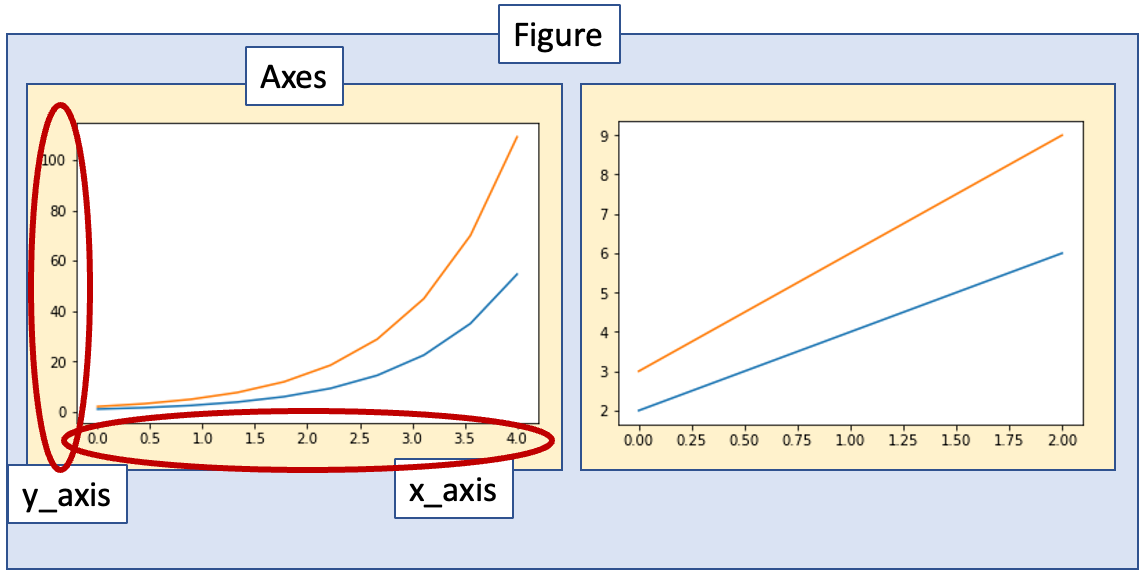

## 2.1 Creating an empty figure

`plt.subplots()` always returns a pair `(fig, ax)`:
- `fig`: the `Figure` object
- `ax`: the `Axes` object (or an array of `Axes` if you create more than one)

`figsize=(width, height)` sets the figure size in inches.

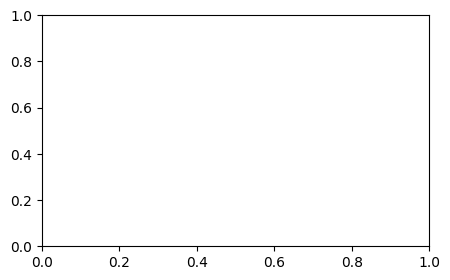

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
plt.show()

---

# 3. Line plot

A line plot draws a sequence of points connected by segments.

`ax.plot(x, y)` takes:
- `x`: a list or NumPy array of x coordinates
- `y`: a list or NumPy array of y coordinates

Calling `.plot()` again on the same `ax` adds a new line to the same plot.

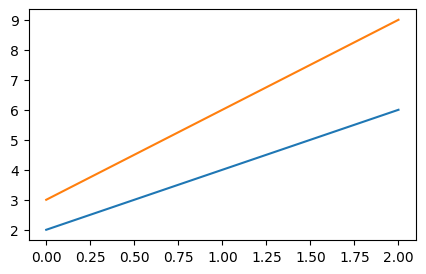

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot([0, 1, 2], [2, 4, 6])
ax.plot([0, 1, 2], [3, 6, 9])

plt.show()

## 3.1 Customising the line plot

The main parameters of `ax.plot()` are:

- **`c`** — colour of the line and markers. Examples: `'red'`, `'#0F0F6B'`, `(0.5, 1, 0.8, 0.8)` (RGBA)
- **`linestyle`** — line style. Examples: `'-'` (solid), `'--'` (dashed), `':'` (dotted), `''` (no line)
- **`marker`** — symbol drawn at each data point. Examples: `'o'`, `'*'`, `'+'`, `'^'`
- **`label`** — label shown in the legend

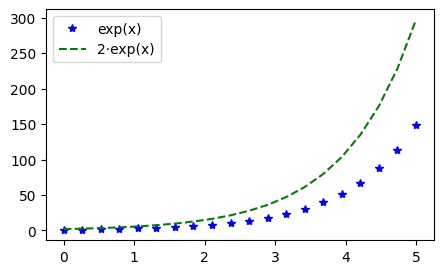

In [8]:
x = np.linspace(0, 5, 20)
y = np.exp(x)

fig, ax = plt.subplots(figsize=(5, 3))

# Blue markers only — no connecting line
ax.plot(x, y, c='blue', linestyle='', marker='*', label='exp(x)')

# Green dashed line, no markers
ax.plot(x, 2 * y, c='green', linestyle='--', label='2·exp(x)')

ax.legend(loc='upper left')

plt.show()

**Try it yourself:** change `linestyle`, `marker` and `c` and re-run the cell.
Try `linestyle='dotted'` and `marker='^'`.

---

# 4. Multiple plots in one figure (subplots)

Passing two integers to `plt.subplots(nrows, ncols)` creates a grid of `Axes`.

- If the figure has **1 row and n columns**: `ax` is a 1D array of shape `(n,)`, indexed with `ax[i]`
- If the figure has **m rows and n columns**: `ax` is a 2D array of shape `(m, n)`, indexed with `ax[i, j]`

`plt.tight_layout()` at the end prevents the subplots from overlapping.

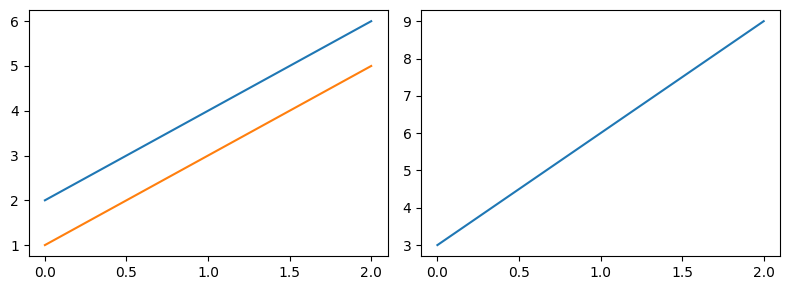

In [9]:
# 1 row, 2 columns → ax has shape (2,)
fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].plot([0, 1, 2], [2, 4, 6])
ax[0].plot([0, 1, 2], [1, 3, 5])

ax[1].plot([0, 1, 2], [3, 6, 9])

plt.tight_layout()
plt.show()

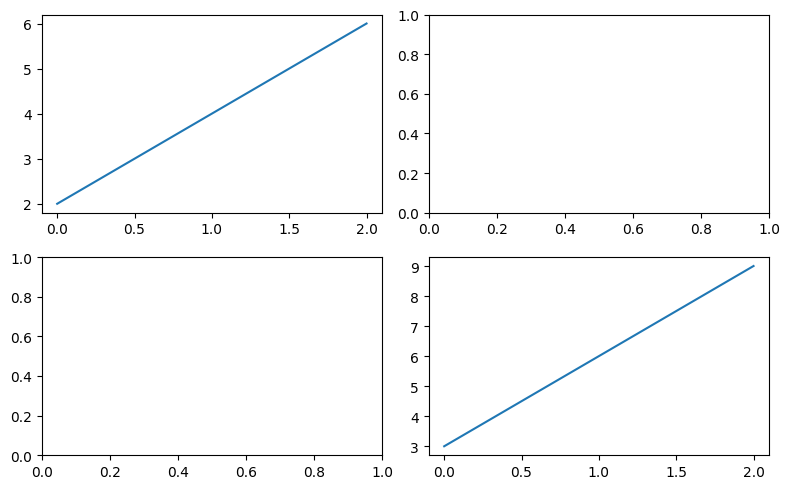

In [10]:
# 2 rows, 2 columns → ax has shape (2, 2)
fig, ax = plt.subplots(2, 2, figsize=(8, 5))

ax[0, 0].plot([0, 1, 2], [2, 4, 6])
ax[1, 1].plot([0, 1, 2], [3, 6, 9])

# The other two Axes remain empty — useful as a starting point for exercises

plt.tight_layout()
plt.show()

**Try it yourself:** add a plot on `ax[0, 1]` and `ax[1, 0]` as well.

---

# 5. Scatter plot

A scatter plot draws individual points, unlike a line plot where points are connected.

The advantage over `ax.plot()` with `linestyle=''` is that **each point can have a different colour and size**.

Main parameters of `ax.scatter(x, y)`:

- **`c`** — array of numeric values: Matplotlib maps them onto a colourmap
- **`s`** — array of numeric values: size of each point (area in dpi)
- **`cmap`** — name of the colourmap to use (e.g. `'viridis'`, `'spring'`, `'plasma'`)

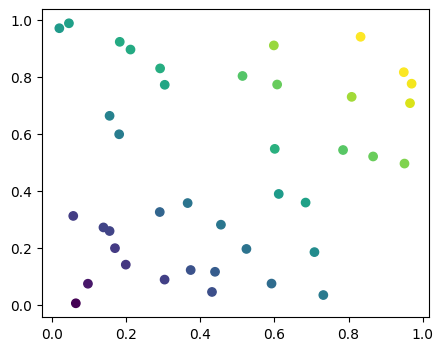

In [11]:
np.random.seed(42)  # for reproducible results
x = np.random.rand(40)
y = np.random.rand(40)

# Colour proportional to the sum x+y
colors = x + y

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x, y, c=colors)
plt.show()

## 5.1 How colour mapping works in scatter

When you pass `c=colors` with a numeric array, Matplotlib:
1. finds the minimum and maximum values in `colors`
2. maps that range onto the full colour spectrum of the chosen colourmap

Example: `c = [101, 120, 50, 60]` → the range is 50–120, and colours are distributed across that interval.

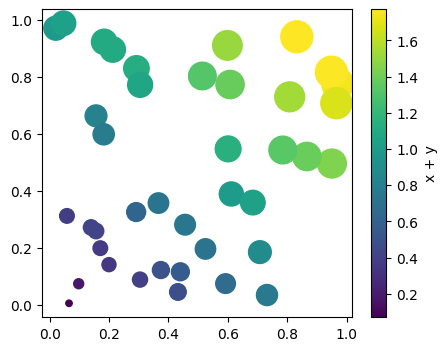

In [13]:
# Scatter with a custom colourmap and variable point size
area = 300 * (x + y)   # size proportional to x+y

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(x, y, c=colors, s=area, cmap='viridis')

# Colour bar: shows the mapping from value to colour
fig.colorbar(scatter, ax=ax, label='x + y')

plt.show()

**Try it yourself:** replace `'viridis'` with `'spring'`, `'plasma'` or `'coolwarm'` and observe the difference.

Full list of colourmaps: https://matplotlib.org/stable/gallery/color/colormap_reference.html

---

# 6. Bar chart

A bar chart displays a sequence of values as vertical bars.

`ax.bar(x, height)` requires:
- `x`: position of each bar on the horizontal axis
- `height`: height of each bar

Tick labels on the x axis are set with the `tick_label` parameter.

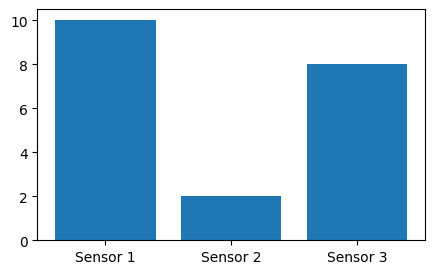

In [14]:
height = [10, 2, 8]
x = [1, 2, 3]
labels = ['Sensor 1', 'Sensor 2', 'Sensor 3']

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x, height, tick_label=labels)
plt.show()

## 6.1 Grouped bar chart

To place multiple bars side by side for the same group of labels, you shift each series slightly.

The idea:
- create base positions with `np.arange(n)`
- shift each series by `+width/2` or `-width/2` from the centre
- set tick positions and labels manually with `ax.set_xticks()` and `ax.set_xticklabels()`

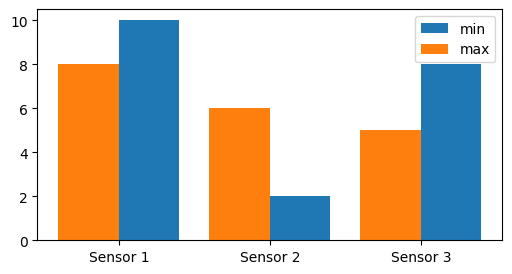

In [15]:
height_min = [10, 2, 8]
height_max = [8, 6, 5]

x = np.arange(3)   # base positions: [0, 1, 2]
width = 0.4        # width of each bar
labels = ['Sensor 1', 'Sensor 2', 'Sensor 3']

fig, ax = plt.subplots(figsize=(6, 3))

# 'min' bars shifted to the right of centre
ax.bar(x + width/2, height_min, width=width, label='min')

# 'max' bars shifted to the left of centre
ax.bar(x - width/2, height_max, width=width, label='max')

ax.set_xticks(x)              # tick positions
ax.set_xticklabels(labels)    # tick labels
ax.legend()

plt.show()

## 6.2 Alternative: bar chart with Pandas

When data is already in a Pandas DataFrame, creating a grouped bar chart is much simpler.

Pandas integrates Matplotlib under the hood via the `.plot.bar()` method.

In [20]:
# You may need to install pandas before

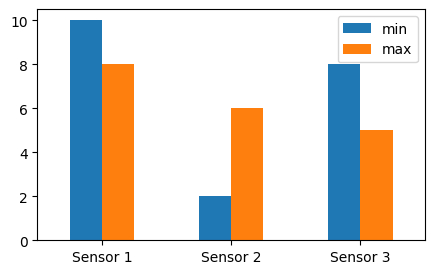

In [21]:
import pandas as pd

df = pd.DataFrame({
    'min': height_min,
    'max': height_max
}, index=labels)

df.plot.bar(figsize=(5, 3), rot=0)   # rot=0 → horizontal tick labels
plt.show()

---

# 7. Adding titles, labels and other elements

A plot without a title and axis labels is hard to interpret.

The most commonly used methods on an `ax` object:

| Method | What it does |
|---|---|
| `ax.set_title('Title')` | Sets the plot title |
| `ax.set_xlabel('Label X')` | Sets the x-axis label |
| `ax.set_ylabel('Label Y')` | Sets the y-axis label |
| `ax.set_xlim(a, b)` | Sets the x-axis limits |
| `ax.set_ylim(a, b)` | Sets the y-axis limits |
| `ax.grid(True)` | Adds a grid |
| `ax.legend()` | Shows the legend |

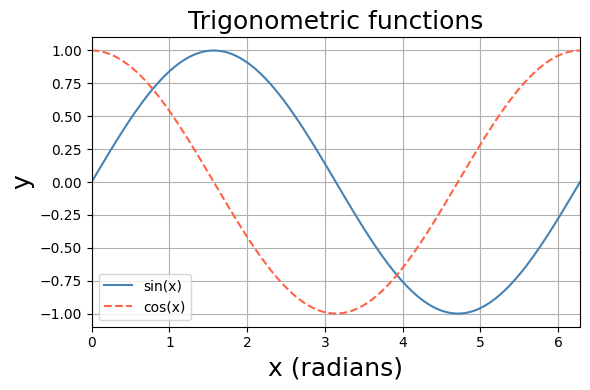

In [23]:
x = np.linspace(0, 2 * np.pi, 100)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x, np.sin(x), label='sin(x)', c='steelblue')
ax.plot(x, np.cos(x), label='cos(x)', c='tomato', linestyle='--')

ax.set_title('Trigonometric functions',fontsize=18)
ax.set_xlabel('x (radians)',fontsize=18)
ax.set_ylabel('y',fontsize=18)
ax.set_xlim(0, 2 * np.pi)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

---

# 8. Saving a figure to file

`fig.savefig('path/name.extension')` saves the current figure.

Supported formats: `.png`, `.jpg`, `.pdf`, `.eps`, `.svg`

Useful parameters:
- `dpi=150` — resolution (dots per inch); default is 100
- `bbox_inches='tight'` — prevents labels from being clipped at the edges

Figure saved as output_matplotlib.png


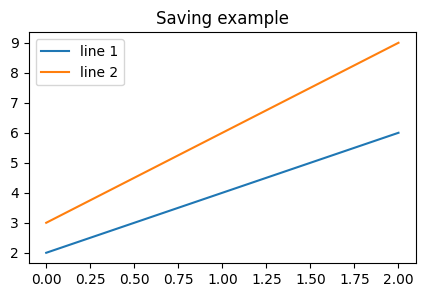

In [24]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot([0, 1, 2], [2, 4, 6], label='line 1')
ax.plot([0, 1, 2], [3, 6, 9], label='line 2')
ax.set_title('Saving example')
ax.legend()

# Save as PNG with high resolution
fig.savefig('output_matplotlib.png', dpi=150, bbox_inches='tight')
print('Figure saved as output_matplotlib.png')

plt.show()

---

# Summary

| What you want to do | How to do it |
|---|---|
| Create a figure | `fig, ax = plt.subplots(figsize=(w, h))` |
| Create multiple plots | `fig, ax = plt.subplots(nrows, ncols)` |
| Line plot | `ax.plot(x, y, c=..., linestyle=..., marker=...)` |
| Scatter plot | `ax.scatter(x, y, c=..., s=..., cmap=...)` |
| Bar chart | `ax.bar(x, height, tick_label=...)` |
| Title and labels | `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` |
| Legend | `ax.legend()` |
| Grid | `ax.grid(True)` |
| Save to file | `fig.savefig('name.png', dpi=150, bbox_inches='tight')` |

**Resources**:
- Official documentation: https://matplotlib.org/
- Gallery (visual examples): https://matplotlib.org/stable/gallery/
- Available colourmaps: https://matplotlib.org/stable/gallery/color/colormap_reference.html